Original Dataset Shape: (648, 36)
Filtered Dataset Shape: (648, 36)
Grouped Dataset Shape: (216, 9)
Number of Unique Herbs: 14

Running GridSearchCV...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

========== MODEL PERFORMANCE ==========
Subset Accuracy: 0.9772727272727273
Hamming Loss: 0.0016233766233766235
Micro F1: 0.9961977186311787
Macro F1: 0.9142857142857144
Training/Evaluating Random Forest ...
Random Forest done.
Training/Evaluating Logistic Regression ...
Logistic Regression done.
Training/Evaluating SVM (Linear) ...
SVM (Linear) done.
Training/Evaluating XGBoost (baseline) ...
XGBoost (baseline) done.


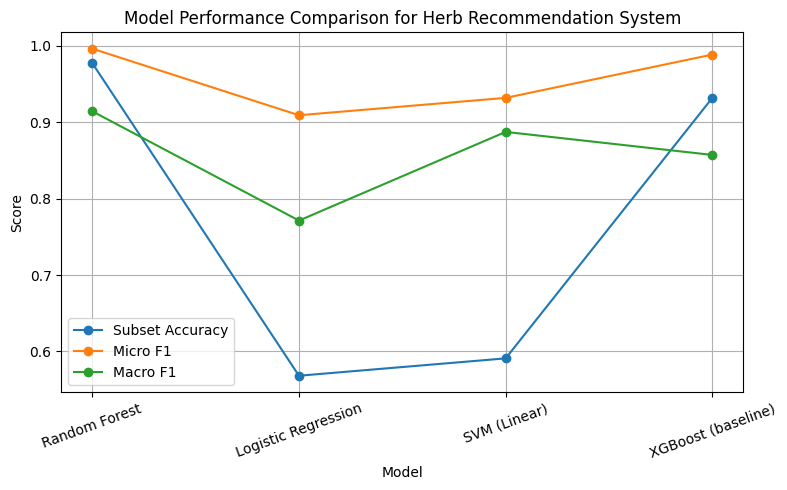


Model saved as herb_recommendation_model.pkl

========== SAMPLE RECOMMENDATION ==========
Recommended Herbs: ('Aloe Vera', 'Chamomile')
Dosage (ml): 9.03
Warnings: []

Generating SHAP explanation...


IndexError: index 24 is out of bounds for axis 1 with size 15

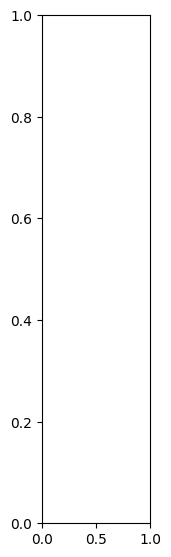

In [5]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    hamming_loss,
    accuracy_score,
    f1_score,
    make_scorer
)

import warnings
warnings.filterwarnings("ignore")

data = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/DSGP/ayurvedic_treatment_database_medical_validation_ready (1).csv"
)

print("Original Dataset Shape:", data.shape)

# NORMALIZE DISEASE NAMES

data["disease"] = (
    data["disease"]
    .astype(str)
    .str.strip()
    .str.lower()
)

TARGET_DISEASES = ["eczema", "acne", "ringworm"]

data = data[data["disease"].isin(TARGET_DISEASES)]

print("Filtered Dataset Shape:", data.shape)

if data.empty:
    raise ValueError(
        "No data left after filtering – check disease labels."
    )

# CLEANING DOSAGE COLUMN

data["dosage_ml"] = (
    data["dosage_ml"]
    .astype(str)
    .str.lower()
    .str.replace("ml", "", regex=False)
    .str.strip()
)

data["dosage_ml"] = pd.to_numeric(
    data["dosage_ml"],
    errors="coerce"
)

data["dosage_ml"] = data["dosage_ml"].fillna(
    data["dosage_ml"].median()
)

# DATA GROUPING (MULTI-HERB TARGET)

group_cols = [
    "disease",
    "severity",
    "age_group",
    "skin_oiliness",
    "skin_sensitivity"
]

grouped = data.groupby(group_cols).agg({
    "herb_name_english": lambda x: list(set(x)),
    "dosage_ml": "mean",
    "contraindications": "first",
    "possible_side_effects": "first"
}).reset_index()

print("Grouped Dataset Shape:", grouped.shape)

# INPUT FEATURES (ONE-HOT Encoding)

X = grouped[
    [
        "disease",
        "severity",
        "age_group",
        "skin_oiliness",
        "skin_sensitivity"
    ]
]

X = pd.get_dummies(X)

# MULTI-LABEL TARGET

mlb = MultiLabelBinarizer()
y = mlb.fit_transform(
    grouped["herb_name_english"]
)

print("Number of Unique Herbs:", len(mlb.classes_))

# TRAIN–TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# GRIDSEARCHCV

hamming_scorer = make_scorer(
    hamming_loss,
    greater_is_better=False
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=hamming_scorer,
    cv=5,
    verbose=1,
    n_jobs=-1
)

print("\nRunning GridSearchCV...")
grid_search.fit(X_train, y_train)

model = grid_search.best_estimator_

print("\nBest Parameters:", grid_search.best_params_)

# MODEL EVALUATION

y_pred = model.predict(X_test)

print("\n========== MODEL PERFORMANCE ==========")
print("Subset Accuracy:", accuracy_score(y_test, y_pred))
print("Hamming Loss:", hamming_loss(y_test, y_pred))
print("Micro F1:", f1_score(y_test, y_pred, average="micro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))


# MODEL COMPARISON

comparison_models = {
    "Random Forest": model,  #tuned RF
    "Logistic Regression": MultiOutputClassifier(LogisticRegression(max_iter=1000)),
    "SVM (Linear)": MultiOutputClassifier(SVC(kernel="linear", probability=True)),
    "XGBoost (baseline)": MultiOutputClassifier(
        xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss")
    )
}

subset_accuracy = []
micro_f1 = []
macro_f1 = []

for name, clf in comparison_models.items():
    print(f"Training/Evaluating {name} ...")

    # Only Random Forest is already trained
    if name != "Random Forest":
        clf.fit(X_train, y_train)

    y_pred_comp = clf.predict(X_test)

    subset_accuracy.append(accuracy_score(y_test, y_pred_comp))
    micro_f1.append(f1_score(y_test, y_pred_comp, average="micro"))
    macro_f1.append(f1_score(y_test, y_pred_comp, average="macro"))

    print(f"{name} done.")

# Plot comparison
plt.figure(figsize=(8,5))
plt.plot(list(comparison_models.keys()), subset_accuracy, marker='o')
plt.plot(list(comparison_models.keys()), micro_f1, marker='o')
plt.plot(list(comparison_models.keys()), macro_f1, marker='o')
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Performance Comparison for Herb Recommendation System")
plt.legend(["Subset Accuracy", "Micro F1", "Macro F1"])
plt.xticks(rotation=20)
plt.grid(True)
plt.tight_layout()
plt.show()

#SAMPLE RECOMMENDATION
joblib.dump(model, "herb_recommendation_model.pkl")
joblib.dump(mlb, "herb_label_binarizer.pkl")

print("\nModel saved as herb_recommendation_model.pkl")

# SAFETY RULE LAYER

def safety_layer(age_group, dosage_ml, contraindications):

    warnings = []

    if str(age_group).lower() == "child" and dosage_ml > 5:
        dosage_ml = 5
        warnings.append("Dosage reduced for child safety")

    if isinstance(contraindications, str):
        if "pregnancy" in contraindications.lower():
            warnings.append(
                "Not recommended during pregnancy"
            )

    return round(dosage_ml, 2), warnings

# RECOMMENDATION FUNCTION

def recommend_ayurvedic_treatment(
    disease,
    severity,
    age_group,
    skin_oiliness,
    skin_sensitivity
):

    disease = str(disease).strip().lower()

    user_input = pd.DataFrame([{
        "disease": disease,
        "severity": severity,
        "age_group": age_group,
        "skin_oiliness": skin_oiliness,
        "skin_sensitivity": skin_sensitivity
    }])

    user_input = pd.get_dummies(user_input)
    user_input = user_input.reindex(
        columns=X.columns,
        fill_value=0
    )

    herb_pred = model.predict(user_input)

    herbs = mlb.inverse_transform(
        herb_pred
    )[0]

    avg_dosage = grouped["dosage_ml"].mean()

    contraindications = grouped[
        "contraindications"
    ].iloc[0]

    dosage, warnings = safety_layer(
        age_group,
        avg_dosage,
        contraindications
    )

    return {
        "Recommended Herbs": herbs,
        "Dosage (ml)": dosage,
        "Warnings": warnings
    }

# SAMPLE TEST

print("\n========== SAMPLE RECOMMENDATION ==========")

sample = recommend_ayurvedic_treatment(
    disease="eczema",
    severity="Moderate",
    age_group="Adult",
    skin_oiliness="Dry",
    skin_sensitivity="High"
)

for k, v in sample.items():
    print(f"{k}: {v}")



print("\nGenerating SHAP explanation...")

rf_model = model.estimators_[0]   # first herb classifier

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

